# Lecture 10: Unsupervised Learning Code Companion

# An Unsupervised Learning Dataset

As a first example of an unsupervised learning dataset, we will use our Iris flower example, but we will discard the labels.

In [1]:
# import standard machine learning libraries
import numpy as np
import pandas as pd
from sklearn import datasets

# Load the Iris dataset
iris = datasets.load_iris()

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

We can visualize this dataset in 2D. Note that we are no longer using label information.

Text(0.5, 1.0, 'Dataset of Iris flowers')

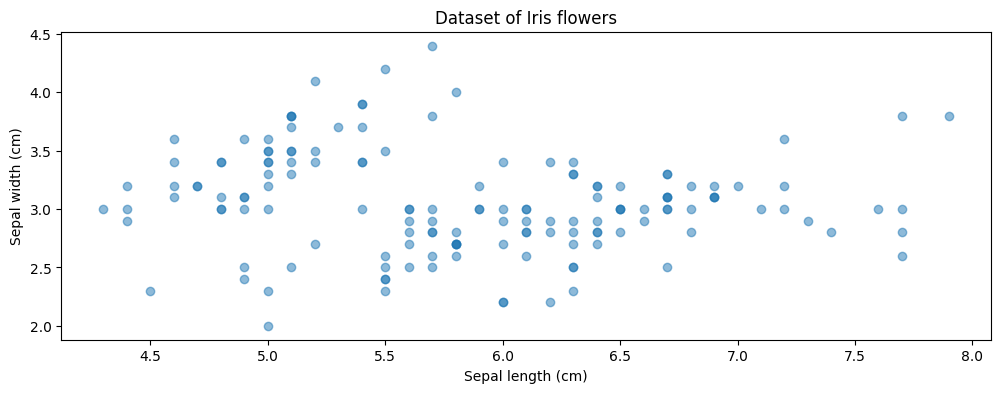

In [2]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

# Visualize the Iris flower dataset
plt.scatter(iris.data[:,0], iris.data[:,1], alpha=0.5)
plt.ylabel("Sepal width (cm)")
plt.xlabel("Sepal length (cm)")
plt.title("Dataset of Iris flowers")

# An Unsupervised Learning Algorithm

We can use this dataset as input to a popular unsupervised learning algorithm, __$K$-means__.

* The algorithm seeks to find $K$ hidden clusters in the data.
<!-- * Each cluster is characterized by its centroid (its mean). -->
* The clusters reveal interesting structure in the data.

In [3]:
# fit K-Means with K=3
from sklearn import cluster
model = cluster.KMeans(n_clusters=3)
model.fit(iris.data[:,[0,1]])

KMeans(n_clusters=3)

Running $K$-means on this dataset identifies three clusters.

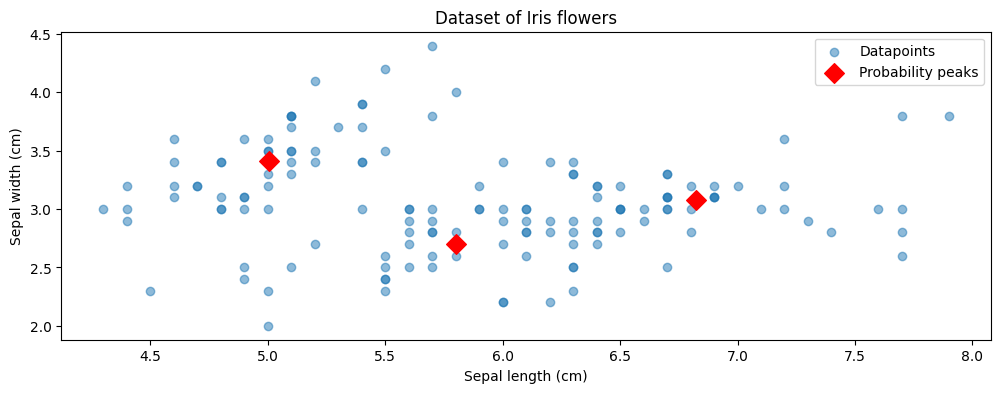

In [4]:
# display the clusters in 2D
plt.scatter(iris.data[:,0], iris.data[:,1], alpha=0.5)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
plt.ylabel("Sepal width (cm)")
plt.xlabel("Sepal length (cm)")
plt.title("Dataset of Iris flowers")
plt.legend(['Datapoints', 'Probability peaks'])

These clusters correspond to the three types of flowers found in the dataset, which we obtain from the labels.

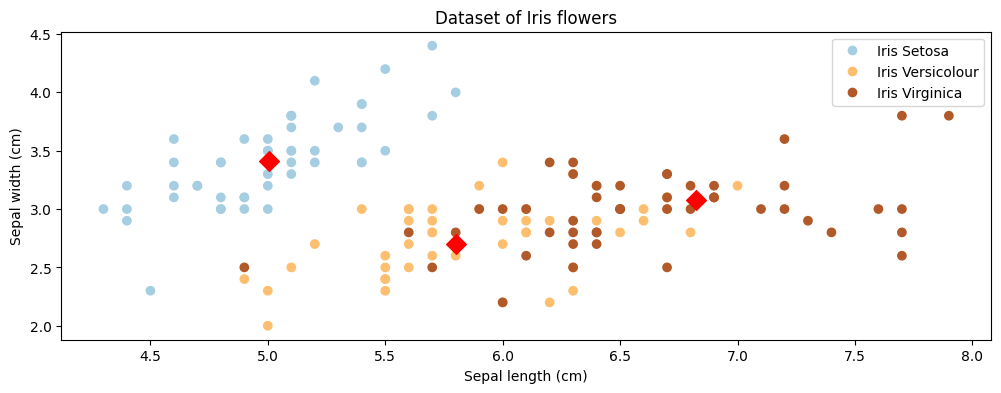

In [5]:
p1 = plt.scatter(iris.data[:,0], iris.data[:,1], alpha=1, c=iris.target, cmap='Paired')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
plt.ylabel("Sepal width (cm)")
plt.xlabel("Sepal length (cm)")
plt.title("Dataset of Iris flowers")
plt.legend(handles=p1.legend_elements()[0], labels=['Iris Setosa', 'Iris Versicolour', 'Iris Virginica'])

# Review: Generalization

In machine learning, __generalization__ is the property of predictive models to achieve good performance on new, heldout data that is distinct from the training set.


# An Unsupervised Learning Dataset

Consider the following dataset, consisting of a mixture of Gaussians.

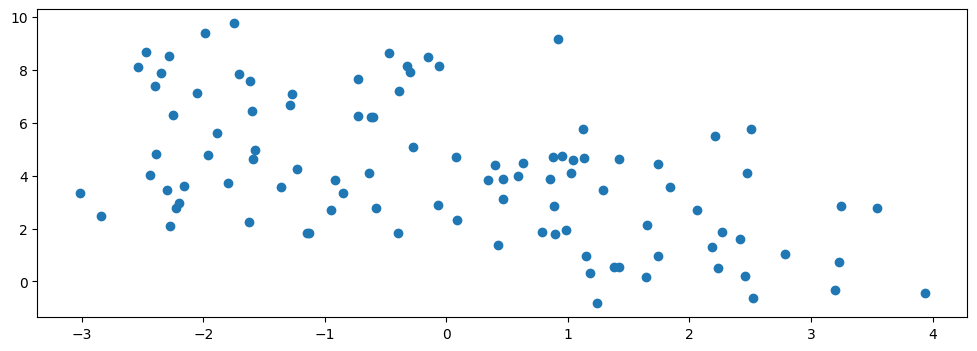

In [6]:
import numpy as np
from sklearn import datasets
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

np.random.seed(0)
X, y = datasets.make_blobs(centers=4)
plt.scatter(X[:,0], X[:,1])

We know the true labels of these clusers, and we can visualize them.

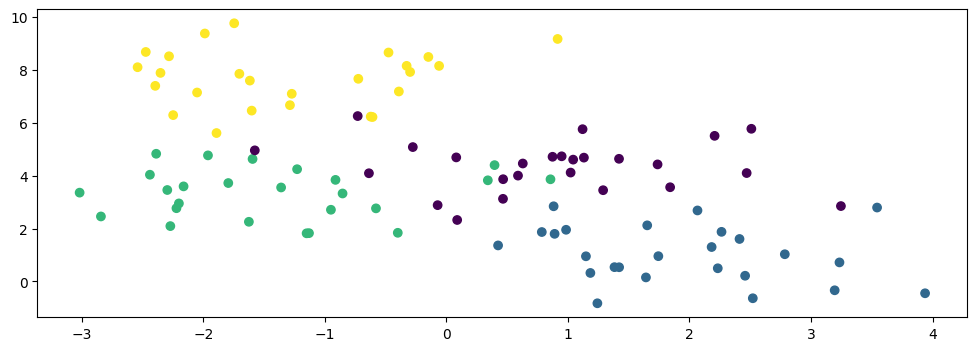

In [7]:
plt.scatter(X[:,0], X[:,1], c=y)

# Underfitting in Unsupervised Learning

Underfitting happens when we are not able to fully learn the signal hidden in the data.

In the context of $K$-Means, this means not capturing all the clusters in the data.

Let's run $K$-Means on our toy dataset.

In [8]:
# fit a K-Means
from sklearn import cluster
model = cluster.KMeans(n_clusters=2)
model.fit(X)

KMeans(n_clusters=2)

The centroids find two distinct components in the data, but they fail to capture the true structure.

K-Means Objective: 462.03


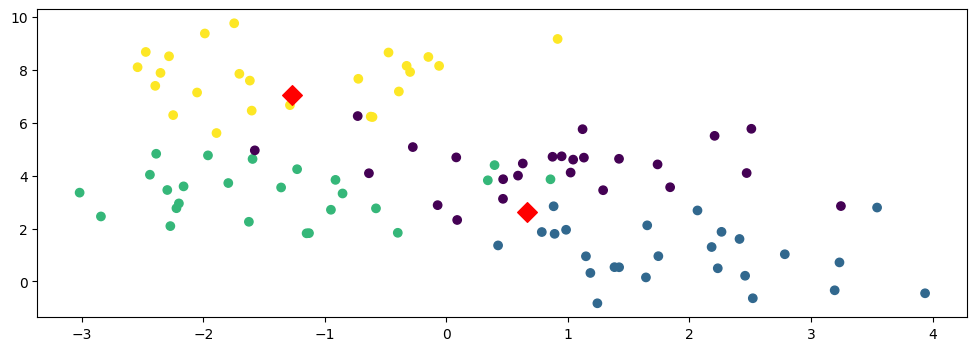

In [9]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
print('K-Means Objective: %.2f' % -model.score(X))

Consider now what happens if we further increase the number of clusters.

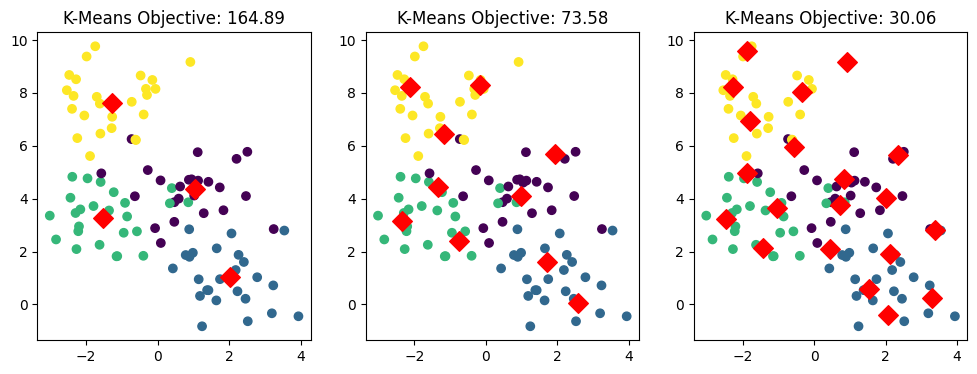

In [10]:
Ks = [4, 10, 20]
f, axes = plt.subplots(1,3)
for k, ax in zip(Ks, axes):
    model = cluster.KMeans(n_clusters=k)
    model.fit(X)
    ax.scatter(X[:,0], X[:,1], c=y)
    ax.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
    ax.set_title('K-Means Objective: %.2f' % -model.score(X))

# Overfitting in Unsupervised Learning

Overfitting happens when we fit the noise, but not the signal.

In our example, this means fitting small, local noise clusters rather than the true global clusters.

K-Means Objective: 5.46


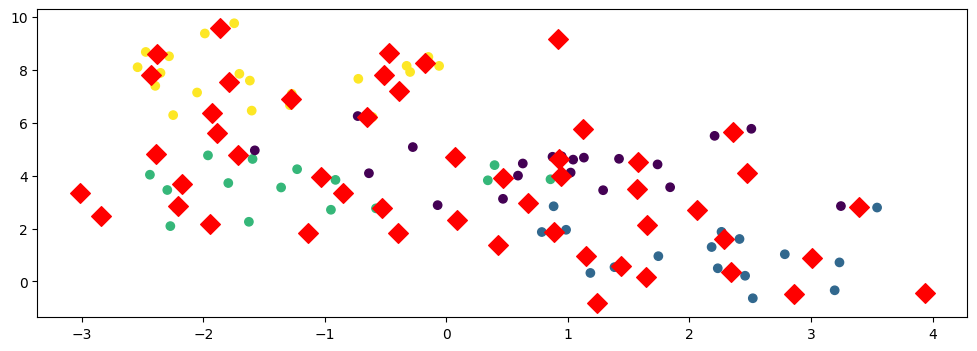

In [11]:
model = cluster.KMeans(n_clusters=50)
model.fit(X)
plt.scatter(X[:,0], X[:,1], c=y)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
print('K-Means Objective: %.2f' % -model.score(X))

We can see the true structure given enough data.

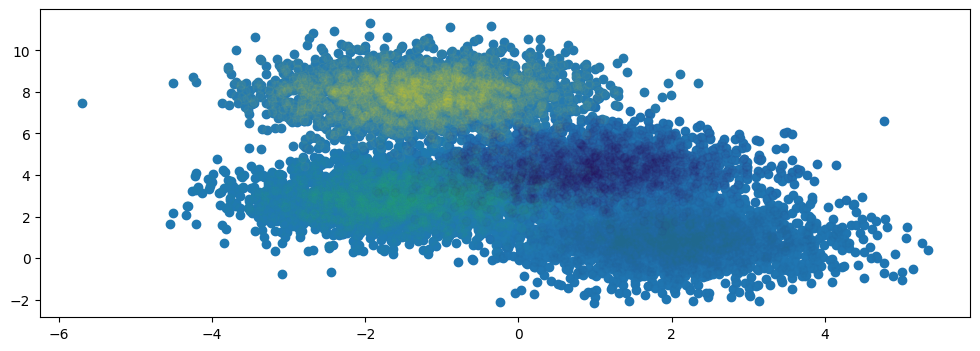

In [12]:
np.random.seed(0)
X, y = datasets.make_blobs(n_samples=10000, centers=4)
plt.scatter(X[:,0], X[:,1])
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.03)

# Data Distribution

We will assume that the dataset is sampled from a probability distribution $\mathbb{P}$, which we will call the *data distribution*. We will denote this as
$$x \sim \mathbb{P}.$$

The dataset $\mathcal{D} = \{x^{(i)} \mid i = 1,2,...,n\}$ consists of *independent and identicaly distributed* (IID) samples from $\mathbb{P}$.

# Data Distribution: IID Sampling

The key assumption in that the training examples are *independent and identicaly distributed* (IID). 
* Each training example is from the same distribution.
* This distribution doesn't depend on previous training examples.

__Example__: Flipping a coin. Each flip has same probability of heads & tails and doesn't depend on previous flips.

__Counter-Example__: Yearly census data. The population in each year will be close to that of the previous year.

# Generalization in Unsupervised Learning

We can think of the data distribution as being the sum of two distinct components $\mathbb{P} = F + E$
1. A signal component $F$ (hidden clusters, speech, low-dimensional data space, etc.)
2. A random noise component $E$

A machine learning model generalizes if it fits the true signal $F$; it overfits if it learns the noise $E$.

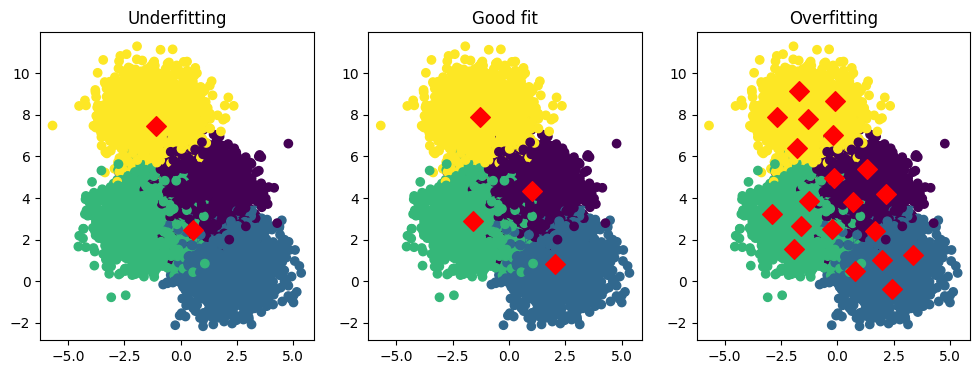

In [13]:
Ks, titles = [2, 4, 20], ['Underfitting', 'Good fit', 'Overfitting']
f, axes = plt.subplots(1,3)
for k, title, ax in zip(Ks, titles, axes):
    model = cluster.KMeans(n_clusters=k)
    model.fit(X)
    ax.scatter(X[:,0], X[:,1], c=y)
    ax.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
    ax.set_title(title)

# The Elbow Method

The Elbow method is a way of tuning hyper-parameters in unsupervised learning.
* We plot the objective function as a function of the hyper-parameter $K$.
* The "elbow" of the curve happens when its rate of decrease substantially slows down.
* The "elbow' is a good guess for the hyperparameter.

In our example, the decrease in objective values slows down after $K=4$, and after that the curve becomes just a line.

Text(0, 0.5, 'Objective Function Value')

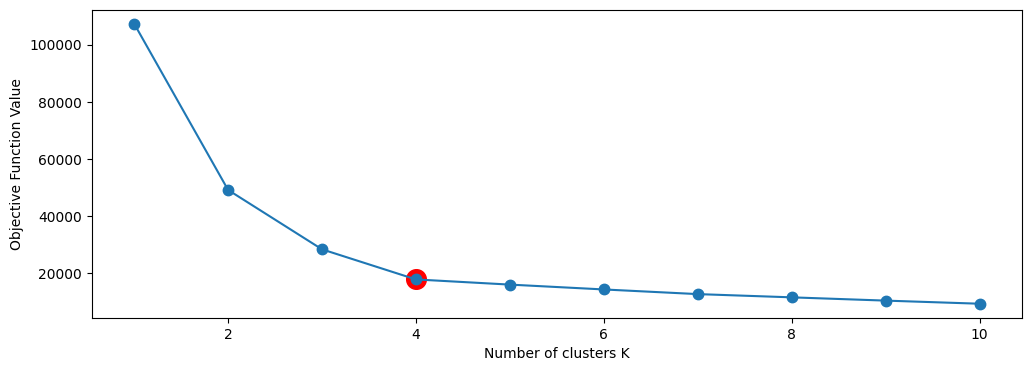

In [14]:
Ks, objs = range(1,11), []
for k in Ks:
    model = cluster.KMeans(n_clusters=k)
    model.fit(X)
    objs.append(-model.score(X))

plt.plot(Ks, objs, '.-', markersize=15)
plt.scatter([4], [objs[3]], s=200, c='r')
plt.xlabel("Number of clusters K")
plt.ylabel("Objective Function Value")